In [189]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, FunctionTransformer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
import pickle


In [123]:
df = pd.read_csv("insurance.csv")

In [124]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Column description

age: age of primary beneficiary

sex: insurance contractor gender. Female, Male

bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9

children: Number of children covered by health insurance / Number of dependents

smoker: Smoking. Yes, No

region: the beneficiary's residential area in the US. Northeast, Southeast, Southwest, Northwest.

charges: Individual medical costs billed by health insurance

In [125]:
# Data Analysis

df.shape

(1338, 7)

In [126]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [128]:
df.duplicated().sum()

np.int64(1)

In [129]:
df = df.drop_duplicates()

In [130]:
df.duplicated().sum()

np.int64(0)

In [131]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# There is no NAN value in the dataset

In [132]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [133]:
df1= df.copy()
df2= df.copy()
df3= df.copy()
df4= df.copy()

In [134]:
df1

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [135]:
heat_df = df1[['age','bmi','children','charges']]
heat_df.head()

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


<Axes: >

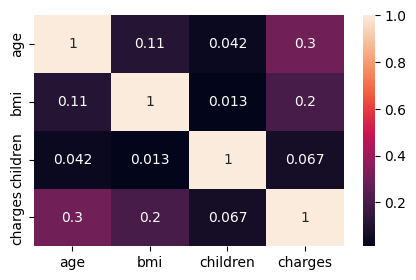

In [136]:
plt.figure(figsize=(5,3))
sns.heatmap(heat_df.corr(),annot= True)

In [137]:
# Encoding 
le = LabelEncoder()

In [138]:
df1['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [139]:
df1['sex'] = le.fit_transform(df1['sex'])
df1['sex'].value_counts()

sex
1    675
0    662
Name: count, dtype: int64

In [140]:
df1['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [141]:
df1['smoker'] = le.fit_transform(df1['smoker'])
df1['smoker'].value_counts()

smoker
0    1063
1     274
Name: count, dtype: int64

In [142]:
ohe = OneHotEncoder(sparse_output= False)

In [143]:
df1['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [144]:
#dummy.head()

In [145]:
dummy = pd.get_dummies(df1['region'],drop_first=True,  prefix='region').astype('int64')
df1 = df1.drop(['region'], axis= 1)
df1 = pd.concat([df1, dummy], axis= 1)
df1.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


<Axes: >

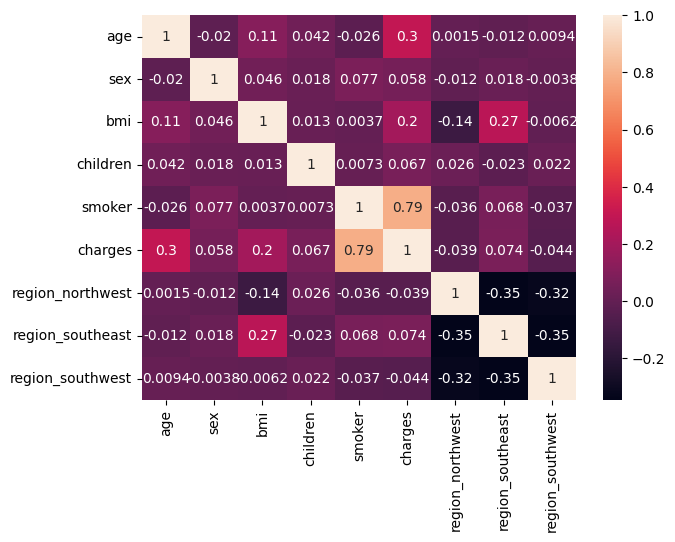

In [146]:
plt.figure(figsize=(7,5))
sns.heatmap(df1.corr(),annot= True)

In [147]:
new_df = df1.copy()

In [148]:
new_df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


<Axes: ylabel='charges'>

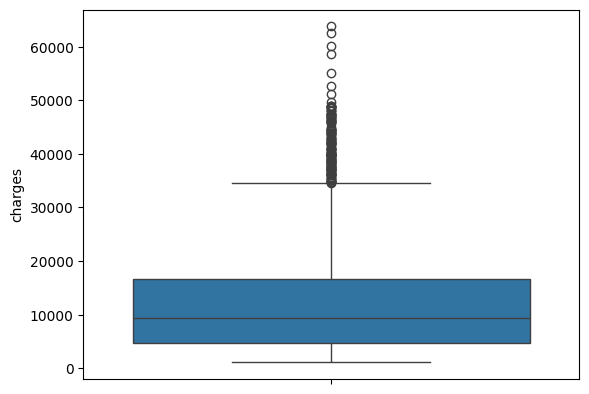

In [149]:
sns.boxplot(new_df['charges'])

<Axes: ylabel='age'>

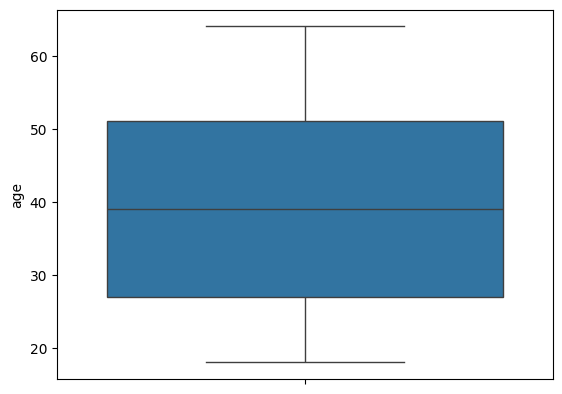

In [150]:
sns.boxplot(new_df['age'])

<Axes: ylabel='bmi'>

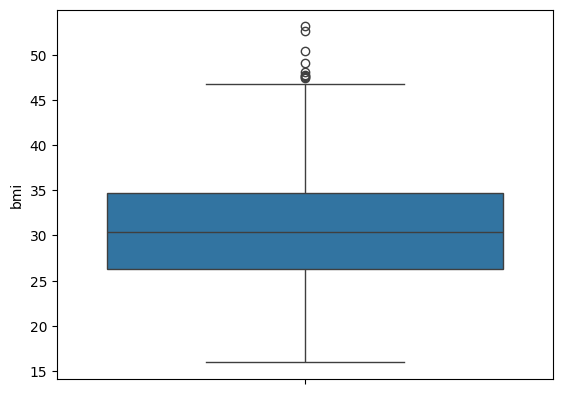

In [151]:
sns.boxplot(new_df['bmi'])

<Axes: ylabel='children'>

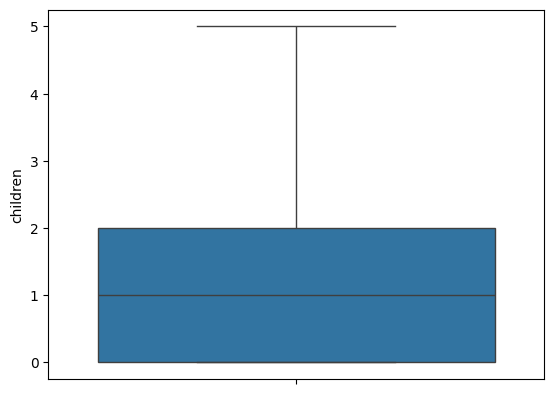

In [152]:
sns.boxplot(new_df['children'])

In [153]:
new_df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

In [154]:
# feature transformation : standard scaler and log transform

In [155]:
ft = FunctionTransformer(np.log1p)

In [156]:
new_df['charges']= ft.fit_transform(new_df['charges'])

In [157]:
new_df['charges']

0        9.734236
1        7.453882
2        8.400763
3        9.998137
4        8.260455
          ...    
1333     9.268755
1334     7.699381
1335     7.396847
1336     7.605365
1337    10.279948
Name: charges, Length: 1337, dtype: float64

In [158]:
scaler = StandardScaler()

In [159]:
new_df['age'] = scaler.fit_transform(new_df[['age']])

In [160]:
new_df['age'].head()

0   -1.440418
1   -1.511647
2   -0.799350
3   -0.443201
4   -0.514431
Name: age, dtype: float64

In [161]:
new_df['bmi'] = scaler.fit_transform(new_df[['bmi']])

In [162]:
new_df['bmi'].head()

0   -0.453160
1    0.509422
2    0.383155
3   -1.305052
4   -0.292456
Name: bmi, dtype: float64

In [163]:
new_df['children'] = scaler.fit_transform(new_df[['children']])

In [164]:
new_df['children'].head()

0   -0.909234
1   -0.079442
2    1.580143
3   -0.909234
4   -0.909234
Name: children, dtype: float64

In [165]:
new_df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,-1.440418,0,-0.453160,-0.909234,1,9.734236,0,0,1
1,-1.511647,1,0.509422,-0.079442,0,7.453882,0,1,0
2,-0.799350,1,0.383155,1.580143,0,8.400763,0,1,0
3,-0.443201,1,-1.305052,-0.909234,0,9.998137,1,0,0
4,-0.514431,1,-0.292456,-0.909234,0,8.260455,1,0,0


# Model implementation

In [166]:
new_df2 = new_df.copy()

In [169]:
x = new_df.drop('charges', axis= 1)
x.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,-1.440418,0,-0.453160,-0.909234,1,0,0,1
1,-1.511647,1,0.509422,-0.079442,0,0,1,0
2,-0.799350,1,0.383155,1.580143,0,0,1,0
3,-0.443201,1,-1.305052,-0.909234,0,1,0,0
4,-0.514431,1,-0.292456,-0.909234,0,1,0,0


In [ ]:
y = new_df['charges']

In [171]:
y.head()

0    9.734236
1    7.453882
2    8.400763
3    9.998137
4    8.260455
Name: charges, dtype: float64

In [173]:
#split the data
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size= .8, random_state= 42 )

In [174]:
xtrain.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
1114,-1.155499,1,-1.009063,-0.909234,0,0,0,0
968,-1.297958,1,-0.806543,0.750351,0,0,0,0
599,0.910164,0,1.125178,0.750351,0,1,0,0
170,1.693691,1,1.772092,-0.909234,0,0,1,0
275,0.554015,0,-0.666338,0.750351,0,0,0,0


In [175]:
ytrain.head()

1114     7.782013
968      8.095863
599     10.418494
170      9.503487
275      9.181616
Name: charges, dtype: float64

In [177]:
xtest.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
900,0.696474,1,-1.336209,-0.909234,0,0,0,0
1064,-0.728120,0,-0.830321,2.409936,0,0,0,1
1256,0.838934,0,0.938238,1.580143,0,1,0,0
298,-0.585661,1,0.611091,1.580143,1,1,0,0
237,-0.585661,1,1.267024,0.750351,0,0,1,0


In [178]:
ytest.head()

900      9.069912
1064     8.649951
1256     9.344674
298     10.564818
237      8.403846
Name: charges, dtype: float64

In [179]:
# model implement

lr = LinearRegression()

In [181]:
model = lr.fit(xtrain, ytrain)
model.score(xtrain, ytrain)

0.7496529355425989

In [182]:
model.score(xtest, ytest)

0.829478626133356

In [183]:
y_pred = model.predict(xtest)
y_pred

array([ 8.93729181,  8.67016676,  9.51818498, 10.27272176,  8.60393505,
        9.204177  , 10.05206352,  8.01858825,  8.95328049,  9.27225545,
        9.35954966, 10.59664829, 10.14208872,  9.60321754,  8.94134584,
        8.97971442,  8.08737522, 10.17012885,  8.26816701,  8.39787474,
        8.03766677, 10.20434728,  9.3489262 , 10.20870807, 10.13504171,
        8.36313184, 10.61795512, 10.88252083,  9.22187642,  9.47224257,
        8.51467145,  9.13324168,  7.86477595,  9.34065086, 10.92012032,
        9.23360106,  8.46885689,  8.58830005, 10.46078282,  8.95544876,
        8.3236868 , 10.5132544 , 10.61645962,  9.23307295,  9.03299446,
        8.24224936,  8.1939741 ,  8.90514365,  8.40073853,  8.79630078,
        8.50786246,  8.86221563, 10.4828183 ,  7.96523682,  8.97110316,
        8.94455307,  9.17311372,  8.25380027, 10.07539194,  8.92618217,
        9.53129475,  8.66256058,  9.39182682,  7.93108155,  9.60393348,
        9.36453711,  8.85366552, 10.23895264,  9.42188705,  9.74

In [184]:
# error analysis

mse = mean_squared_error(ytest, y_pred)
mse

0.15822472253428826

In [187]:
mae = mean_absolute_error(ytest, y_pred)
mae

0.26065645157362366

In [188]:
#evaluation

r2score = r2_score(ytest, y_pred)
r2score

0.829478626133356

# save the model in pickle

In [190]:
pickle.dump(model, open("Linear_model.pkl", 'wb'))